# Deterministic FWHT Compression for PSD Frames

This notebook refactors the full deterministic codec described in `docs/main.tex` and evaluates:

1. **Rate-distortion** (bits/frame vs MSE/NMSE/SNR).
2. **Sensing consistency** (occupancy mismatch, peak/centroid/occupied-bandwidth errors).
3. **Computational cost**:
   - Theoretical operation counts per frame.
   - Empirical runtime (encode/decode time per frame).

## Implemented pipeline

`S_t(ω)` → decimation → standardization (`b_t`) → invertible non-linearity → FWHT → top-`K` + quantization (`b_s`) → inverse FWHT → inverse map → de-standardization → upsampling.

The implementation is deterministic and training-free, matching the FWHT section of `docs/main.tex`.


In [20]:
from __future__ import annotations

from dataclasses import dataclass, replace
from pathlib import Path
from time import perf_counter
from typing import Dict, Iterable, Literal, Tuple

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray

plt.style.use('seaborn-v0_8-whitegrid')

Array1D = NDArray[np.float64]


In [21]:
@dataclass(frozen=True)
class StandardizationSideInfo:
    """Stores per-frame affine normalization parameters transmitted as side information."""

    mean: float  # Mean of decimated PSD frame
    std: float   # Standard deviation of decimated PSD frame


@dataclass(frozen=True)
class FWHTConfig:
    """Holds deterministic FWHT codec hyperparameters for one operating point."""

    decimation_factor_bins: int = 2
    top_k_coeffs: int = 64
    quant_step: float = 0.02
    nonlinear_mode: Literal['identity', 'signed_log1p', 'asinh'] = 'signed_log1p'
    nonlinear_alpha: float = 2.0
    side_info_bits_per_param: int = 16
    value_bits_per_coeff: int = 16


@dataclass(frozen=True)
class FWHTPacket:
    """Represents one compressed frame payload `(b_s, b_t)` in deterministic form."""

    original_length_bins: int
    decimated_length_bins: int
    hadamard_length_bins: int
    side_info: StandardizationSideInfo
    topk_indices: NDArray[np.int64]
    quantized_values: NDArray[np.int32]
    quant_step: float
    nonlinear_mode: Literal['identity', 'signed_log1p', 'asinh']
    nonlinear_alpha: float


In [22]:
def load_psd_dataset(
    dataset_path: Path,  # Path to the NPZ dataset with PSD frames
) -> Tuple[NDArray[np.float32], NDArray[np.float64], Dict[str, object]]:  # (frames, freqs_hz, metadata)
    """Loads PSD frames, frequency grid, and scalar metadata from disk.

    Purpose:
    - Provide a deterministic data source for FWHT compression experiments.

    Parameters:
    - dataset_path: NPZ file expected to contain `X`, `freqs_hz`, `gmin`, `gmax`, and `normalize_mode`.

    Returns:
    - Tuple with PSD matrix `[num_frames, num_bins]`, frequency grid `[Hz]`, and metadata.

    Side effects:
    - Reads one NPZ file from disk.
    """
    if not dataset_path.exists():
        raise FileNotFoundError(f'Dataset not found: {dataset_path}')

    # Load arrays and cast to stable dtypes for reproducible processing.
    dataset_npz = np.load(dataset_path, allow_pickle=True)
    frames_psd = dataset_npz['X'].astype(np.float32)
    freqs_hz = dataset_npz['freqs_hz'].astype(np.float64)

    metadata: Dict[str, object] = {
        'gmin': float(dataset_npz['gmin']),
        'gmax': float(dataset_npz['gmax']),
        'normalize_mode': str(dataset_npz['normalize_mode']),
    }
    return frames_psd, freqs_hz, metadata


def decimate_frequency_bins(
    frame_psd: Array1D,              # Input PSD frame on original grid
    decimation_factor_bins: int,     # Number of bins averaged into one bin
) -> Array1D:                        # Decimated PSD frame
    """Downsamples a PSD frame by block averaging contiguous frequency bins.

    Purpose:
    - Implement the deterministic decimation stage from `docs/main.tex`.

    Parameters:
    - frame_psd: One-dimensional PSD frame.
    - decimation_factor_bins: Positive integer pooling factor.

    Returns:
    - Decimated PSD frame of length `floor(N / decimation_factor_bins)`.

    Side effects:
    - None.
    """
    if frame_psd.ndim != 1:
        raise ValueError('frame_psd must be one-dimensional')
    if decimation_factor_bins < 1:
        raise ValueError('decimation_factor_bins must be >= 1')

    if decimation_factor_bins == 1:
        return frame_psd.astype(np.float64, copy=True)

    # Trim trailing bins that do not form a complete pooling block.
    trimmed_length = (frame_psd.size // decimation_factor_bins) * decimation_factor_bins
    if trimmed_length == 0:
        raise ValueError('decimation_factor_bins is too large for frame length')

    trimmed = frame_psd[:trimmed_length]

    # Average each block to reduce dimensionality while preserving coarse spectral trends.
    decimated = trimmed.reshape(-1, decimation_factor_bins).mean(axis=1)
    return decimated.astype(np.float64)


def upsample_linear(
    frame_decimated: Array1D,        # Reconstructed decimated-domain frame
    target_length_bins: int,         # Required output length on original grid
) -> Array1D:                        # Upsampled frame on original grid
    """Upsamples a decimated frame to the original grid using linear interpolation.

    Purpose:
    - Implement inverse `U_{M/K}` in a deterministic and lightweight way.

    Parameters:
    - frame_decimated: One-dimensional frame on reduced grid.
    - target_length_bins: Number of bins in the original PSD frame.

    Returns:
    - One-dimensional reconstructed frame with `target_length_bins` samples.

    Side effects:
    - None.
    """
    if frame_decimated.ndim != 1:
        raise ValueError('frame_decimated must be one-dimensional')
    if target_length_bins < 1:
        raise ValueError('target_length_bins must be >= 1')

    if frame_decimated.size == 1:
        return np.full((target_length_bins,), float(frame_decimated[0]), dtype=np.float64)

    # Interpolate on normalized coordinates so the method is independent of absolute bin count.
    source_axis = np.linspace(0.0, 1.0, frame_decimated.size)
    target_axis = np.linspace(0.0, 1.0, target_length_bins)
    return np.interp(target_axis, source_axis, frame_decimated).astype(np.float64)


def standardize_frame(
    frame: Array1D,             # Input frame to standardize
    eps: float = 1e-8,          # Lower bound for numerical stability
) -> Tuple[Array1D, StandardizationSideInfo]:  # (standardized frame, side info)
    """Standardizes one frame and emits side information for exact inversion.

    Purpose:
    - Implement `Std(S'_t; t_t)` and side-information payload `b_t`.

    Parameters:
    - frame: One-dimensional decimated PSD frame.
    - eps: Minimum allowed standard deviation.

    Returns:
    - Standardized frame and `(mean, std)` side-information object.

    Side effects:
    - None.
    """
    if frame.ndim != 1:
        raise ValueError('frame must be one-dimensional')

    # Estimate per-frame affine normalization parameters.
    mean_value = float(np.mean(frame))
    std_value = float(np.std(frame))
    safe_std = max(std_value, eps)

    standardized = (frame - mean_value) / safe_std
    side_info = StandardizationSideInfo(mean=mean_value, std=safe_std)
    return standardized.astype(np.float64), side_info


def destandardize_frame(
    standardized: Array1D,                # Standardized frame
    side_info: StandardizationSideInfo,   # Side-information (mean, std)
) -> Array1D:                             # Frame in original decimated scale
    """Inverts standardization using transmitted side-information parameters.

    Purpose:
    - Recover decimated-domain PSD values before upsampling.

    Parameters:
    - standardized: One-dimensional standardized frame.
    - side_info: Mean and standard deviation used by the encoder.

    Returns:
    - One-dimensional frame in the original decimated value scale.

    Side effects:
    - None.
    """
    if standardized.ndim != 1:
        raise ValueError('standardized must be one-dimensional')

    # Reverse affine transform: x = z * std + mean.
    return (standardized * side_info.std + side_info.mean).astype(np.float64)


In [23]:
def apply_nonlinear_map(
    values: Array1D,                                     # Standardized values
    mode: Literal['identity', 'signed_log1p', 'asinh'], # Mapping family
    alpha: float,                                        # Mapping shape parameter
) -> Array1D:                                            # Transformed values
    """Applies invertible pointwise map `g_nl(.)` before transform coding.

    Purpose:
    - Compress dynamic range so sparse transform coding is more effective.

    Parameters:
    - values: One-dimensional standardized vector.
    - mode: Non-linear map (`identity`, `signed_log1p`, `asinh`).
    - alpha: Positive shape parameter controlling non-linearity strength.

    Returns:
    - One-dimensional transformed vector with the same length as input.

    Side effects:
    - None.
    """
    if values.ndim != 1:
        raise ValueError('values must be one-dimensional')
    if alpha <= 0.0:
        raise ValueError('alpha must be > 0')

    # Keep an identity branch for ablation and sanity checks.
    if mode == 'identity':
        return values.astype(np.float64)

    # Signed log-like compression for heavy-tailed standardized PSD values.
    if mode == 'signed_log1p':
        return (np.sign(values) * np.log1p(alpha * np.abs(values)) / alpha).astype(np.float64)

    # asinh behaves linearly near zero and logarithmically at large magnitudes.
    if mode == 'asinh':
        return (np.arcsinh(alpha * values) / alpha).astype(np.float64)

    raise ValueError(f'Unsupported nonlinear mode: {mode}')


def invert_nonlinear_map(
    transformed: Array1D,                                # Values in transformed domain
    mode: Literal['identity', 'signed_log1p', 'asinh'], # Mapping family
    alpha: float,                                        # Shape parameter from forward map
) -> Array1D:                                            # Recovered standardized values
    """Inverts the pointwise non-linear map used at the encoder.

    Purpose:
    - Recover standardized-domain values before de-standardization.

    Parameters:
    - transformed: One-dimensional transformed vector.
    - mode: Non-linear map identifier used in encoding.
    - alpha: Positive shape parameter from encoding.

    Returns:
    - One-dimensional vector in standardized domain.

    Side effects:
    - None.
    """
    if transformed.ndim != 1:
        raise ValueError('transformed must be one-dimensional')
    if alpha <= 0.0:
        raise ValueError('alpha must be > 0')

    # Apply analytical inverse for each supported mode.
    if mode == 'identity':
        return transformed.astype(np.float64)
    if mode == 'signed_log1p':
        return (
            np.sign(transformed) * np.expm1(alpha * np.abs(transformed)) / alpha
        ).astype(np.float64)
    if mode == 'asinh':
        return (np.sinh(alpha * transformed) / alpha).astype(np.float64)

    raise ValueError(f'Unsupported nonlinear mode: {mode}')


def next_power_of_two(
    length: int,  # Input vector length [bins]
) -> int:         # Smallest power of two >= length
    """Returns the power-of-two length required by FWHT.

    Purpose:
    - Enforce FWHT input length constraints via zero-padding length selection.

    Parameters:
    - length: Positive integer vector length.

    Returns:
    - Next power-of-two integer.

    Side effects:
    - None.
    """
    if length < 1:
        raise ValueError('length must be >= 1')
    return 1 << (length - 1).bit_length()


def pad_with_zeros(
    values: Array1D,      # Input vector
    target_length: int,   # Desired output length [bins]
) -> Array1D:             # Right-zero-padded vector
    """Pads a vector with trailing zeros up to a target length.

    Purpose:
    - Build FWHT-compatible vectors when decimated length is not a power of two.

    Parameters:
    - values: One-dimensional input vector.
    - target_length: Target length with `target_length >= len(values)`.

    Returns:
    - Padded vector as float64.

    Side effects:
    - None.
    """
    if values.ndim != 1:
        raise ValueError('values must be one-dimensional')
    if target_length < values.size:
        raise ValueError('target_length must be >= values length')

    if target_length == values.size:
        return values.astype(np.float64)

    # Allocate once and copy only the valid prefix.
    padded = np.zeros(target_length, dtype=np.float64)
    padded[: values.size] = values
    return padded


def fwht_orthonormal(
    values: Array1D,  # Input vector with length N=2^m
) -> Array1D:         # FWHT coefficients c=(1/sqrt(N))*H_N*x
    """Computes orthonormal Fast Walsh-Hadamard Transform.

    Purpose:
    - Implement `c_t = (1/sqrt(N_H)) H_{N_H} sigma_t` from `docs/main.tex`.

    Parameters:
    - values: One-dimensional vector with power-of-two length.

    Returns:
    - Orthonormal FWHT coefficients.

    Side effects:
    - None.
    """
    if values.ndim != 1:
        raise ValueError('values must be one-dimensional')

    n_bins = values.size
    if n_bins < 1 or (n_bins & (n_bins - 1)) != 0:
        raise ValueError('FWHT input length must be a power of two')

    transformed = values.astype(np.float64, copy=True)

    # Apply butterfly stages in-place to achieve O(N log2 N) complexity.
    block_size = 1
    while block_size < n_bins:
        step = block_size * 2
        for start in range(0, n_bins, step):
            upper = transformed[start : start + block_size].copy()
            lower = transformed[start + block_size : start + step].copy()
            transformed[start : start + block_size] = upper + lower
            transformed[start + block_size : start + step] = upper - lower
        block_size = step

    # Normalize so FWHT is orthonormal and self-inverse.
    transformed /= np.sqrt(n_bins)
    return transformed


def inverse_fwht_orthonormal(
    coefficients: Array1D,  # FWHT coefficients (N=2^m)
) -> Array1D:               # Reconstructed vector in original domain
    """Applies inverse orthonormal FWHT.

    Purpose:
    - Recover transformed-domain signal from sparse coefficient vector.

    Parameters:
    - coefficients: One-dimensional FWHT coefficient vector.

    Returns:
    - Reconstructed vector in transformed signal domain.

    Side effects:
    - None.

    Assumptions:
    - For orthonormal Hadamard, inverse equals forward transform.
    """
    return fwht_orthonormal(coefficients)


def select_topk_coefficients(
    coefficients: Array1D,   # Full coefficient vector
    top_k_coeffs: int,       # Number of retained coefficients
) -> Tuple[NDArray[np.int64], Array1D]:  # (indices, values)
    """Selects K largest-magnitude FWHT coefficients using partial selection.

    Purpose:
    - Build sparse support set `Omega_t` without full sorting.

    Parameters:
    - coefficients: One-dimensional transform vector.
    - top_k_coeffs: Requested number of retained coefficients.

    Returns:
    - Sorted support indices and corresponding coefficient values.

    Side effects:
    - None.
    """
    if coefficients.ndim != 1:
        raise ValueError('coefficients must be one-dimensional')
    if top_k_coeffs < 0:
        raise ValueError('top_k_coeffs must be >= 0')

    if top_k_coeffs == 0:
        return np.empty((0,), dtype=np.int64), np.empty((0,), dtype=np.float64)

    # Use argpartition for near-linear complexity in support selection.
    k_effective = min(top_k_coeffs, coefficients.size)
    support = np.argpartition(np.abs(coefficients), -k_effective)[-k_effective:]
    support = np.sort(support.astype(np.int64))
    return support, coefficients[support].astype(np.float64)


def quantize_uniform(
    values: Array1D,      # Continuous coefficient values
    quant_step: float,    # Uniform quantization step
) -> NDArray[np.int32]:   # Integer quantization indices
    """Applies scalar uniform quantization to retained coefficients.

    Purpose:
    - Build compact integer payload for FWHT top-K values.

    Parameters:
    - values: One-dimensional floating-point coefficients.
    - quant_step: Positive step size for uniform quantizer.

    Returns:
    - One-dimensional int32 quantization indices.

    Side effects:
    - None.
    """
    if values.ndim != 1:
        raise ValueError('values must be one-dimensional')
    if quant_step <= 0.0:
        raise ValueError('quant_step must be > 0')

    # Round to nearest quantization level in integer index space.
    return np.rint(values / quant_step).astype(np.int32)


def dequantize_uniform(
    q_values: NDArray[np.int32],  # Integer quantization indices
    quant_step: float,            # Uniform quantization step
) -> Array1D:                     # Reconstructed floating-point values
    """Reconstructs coefficients from scalar uniform quantization indices.

    Purpose:
    - Recover quantized coefficient amplitudes at decoder.

    Parameters:
    - q_values: One-dimensional integer code vector.
    - quant_step: Positive quantization step.

    Returns:
    - One-dimensional float64 vector of reconstructed values.

    Side effects:
    - None.
    """
    if q_values.ndim != 1:
        raise ValueError('q_values must be one-dimensional')
    if quant_step <= 0.0:
        raise ValueError('quant_step must be > 0')

    return (q_values.astype(np.float64) * quant_step).astype(np.float64)


def build_sparse_vector(
    length: int,                   # Length of sparse output vector
    indices: NDArray[np.int64],    # Non-zero indices
    values: Array1D,               # Non-zero values
) -> Array1D:                      # Sparse vector with zeros outside support
    """Builds sparse coefficient vector from index-value payload.

    Purpose:
    - Reconstruct `	ilde{c}_t` used by inverse FWHT at decoder.

    Parameters:
    - length: Output vector length.
    - indices: One-dimensional non-zero positions.
    - values: One-dimensional non-zero values matching `indices`.

    Returns:
    - Sparse float64 vector of length `length`.

    Side effects:
    - None.
    """
    if length < 1:
        raise ValueError('length must be >= 1')
    if indices.ndim != 1 or values.ndim != 1:
        raise ValueError('indices and values must be one-dimensional')
    if indices.size != values.size:
        raise ValueError('indices and values must have the same size')
    if np.any(indices < 0) or np.any(indices >= length):
        raise ValueError('indices must be within [0, length)')

    # Fill retained coordinates and keep all others exactly at zero.
    sparse = np.zeros(length, dtype=np.float64)
    sparse[indices] = values
    return sparse


In [24]:
def compress_fwht_frame(
    frame_psd: Array1D,   # Input PSD frame `S_t(omega)`
    config: FWHTConfig,   # Deterministic codec configuration
) -> FWHTPacket:          # Packet with side info and sparse quantized payload
    """Encodes one frame using deterministic FWHT compression pipeline.

    Purpose:
    - Implement encoder path from `docs/main.tex`:
      decimation -> standardization -> non-linear map -> FWHT -> top-K -> quantization.

    Parameters:
    - frame_psd: One-dimensional PSD frame on original frequency grid.
    - config: Hyperparameters controlling decimation, sparsity, and quantization.

    Returns:
    - `FWHTPacket` containing all information required for deterministic decoding.

    Side effects:
    - None.
    """
    if frame_psd.ndim != 1:
        raise ValueError('frame_psd must be one-dimensional')

    # 1) Decimate frequency bins to reduce dimensionality.
    frame_decimated = decimate_frequency_bins(frame_psd, config.decimation_factor_bins)

    # 2) Standardize and export side information (`b_t`).
    frame_standardized, side_info = standardize_frame(frame_decimated)

    # 3) Apply optional invertible non-linear map.
    sigma_t = apply_nonlinear_map(
        frame_standardized,
        mode=config.nonlinear_mode,
        alpha=config.nonlinear_alpha,
    )

    # 4) Zero-pad transformed signal to FWHT-compatible length.
    hadamard_length_bins = next_power_of_two(sigma_t.size)
    sigma_padded = pad_with_zeros(sigma_t, hadamard_length_bins)

    # 5) Transform and keep top-K magnitude coefficients.
    coefficients = fwht_orthonormal(sigma_padded)
    topk_indices, topk_values = select_topk_coefficients(coefficients, config.top_k_coeffs)

    # 6) Quantize retained coefficients to build main payload (`b_s`).
    quantized_values = quantize_uniform(topk_values, config.quant_step)

    return FWHTPacket(
        original_length_bins=int(frame_psd.size),
        decimated_length_bins=int(frame_decimated.size),
        hadamard_length_bins=int(hadamard_length_bins),
        side_info=side_info,
        topk_indices=topk_indices,
        quantized_values=quantized_values,
        quant_step=float(config.quant_step),
        nonlinear_mode=config.nonlinear_mode,
        nonlinear_alpha=float(config.nonlinear_alpha),
    )


def decompress_fwht_frame(
    packet: FWHTPacket,  # Encoded packet produced by `compress_fwht_frame`
) -> Array1D:            # Reconstructed PSD frame on original grid
    """Decodes one frame from deterministic FWHT payload.

    Purpose:
    - Implement decoder path from `docs/main.tex`:
      sparse coeffs -> inverse FWHT -> inverse map -> de-standardization -> upsampling.

    Parameters:
    - packet: Encoded payload containing side-information and sparse coefficients.

    Returns:
    - Reconstructed PSD frame with `packet.original_length_bins` bins.

    Side effects:
    - None.
    """
    # 1) Reconstruct quantized coefficient amplitudes.
    dequantized_values = dequantize_uniform(packet.quantized_values, packet.quant_step)

    # 2) Rebuild sparse transform vector and apply inverse FWHT.
    sparse_coefficients = build_sparse_vector(
        length=packet.hadamard_length_bins,
        indices=packet.topk_indices,
        values=dequantized_values,
    )
    sigma_padded_hat = inverse_fwht_orthonormal(sparse_coefficients)

    # 3) Remove right-padding to recover decimated transformed-domain length.
    sigma_hat = sigma_padded_hat[: packet.decimated_length_bins]

    # 4) Invert non-linearity and de-standardize.
    standardized_hat = invert_nonlinear_map(
        sigma_hat,
        mode=packet.nonlinear_mode,
        alpha=packet.nonlinear_alpha,
    )
    frame_decimated_hat = destandardize_frame(standardized_hat, packet.side_info)

    # 5) Upsample to original number of frequency bins.
    return upsample_linear(frame_decimated_hat, packet.original_length_bins)


def estimate_payload_bits(
    packet: FWHTPacket,  # Encoded packet
    config: FWHTConfig,  # Bit-depth assumptions
) -> Dict[str, float]:   # Detailed and aggregate bit counts
    """Estimates per-frame bitrate components for FWHT payload.

    Purpose:
    - Quantify rate term `L_b(t) = L_{b_s}(t) + L_{b_t}(t)` from the formulation.

    Parameters:
    - packet: Encoded frame payload.
    - config: Side-info and value bit assumptions.

    Returns:
    - Dictionary with side-info bits, index bits, value bits, header bits, and totals.

    Side effects:
    - None.
    """
    # Side information carries per-frame (mean, std).
    b_t_bits = int(2 * config.side_info_bits_per_param)

    # Index payload uses fixed-length index coding over Hadamard domain.
    index_bits_per_symbol = int(np.ceil(np.log2(max(packet.hadamard_length_bins, 2))))
    b_s_index_bits = int(packet.topk_indices.size * index_bits_per_symbol)

    # Quantized coefficient payload uses fixed-width integer symbols.
    b_s_value_bits = int(packet.quantized_values.size * config.value_bits_per_coeff)

    # Minimal fixed header for signaling dimensions and K.
    header_bits = int(np.ceil(np.log2(packet.hadamard_length_bins + 1))) + 16

    total_bits = b_t_bits + b_s_index_bits + b_s_value_bits + header_bits
    original_bits_float32 = int(packet.original_length_bins * 32)
    compression_ratio = float(original_bits_float32 / max(total_bits, 1))

    return {
        'b_t_bits': float(b_t_bits),
        'b_s_index_bits': float(b_s_index_bits),
        'b_s_value_bits': float(b_s_value_bits),
        'header_bits': float(header_bits),
        'total_bits': float(total_bits),
        'original_bits_float32': float(original_bits_float32),
        'compression_ratio': compression_ratio,
    }


def occupancy_mask(
    frame_psd: Array1D,    # PSD frame
    threshold: float,      # Occupancy threshold on PSD magnitude
) -> NDArray[np.bool_]:    # Binary occupancy mask per bin
    """Builds binary occupancy mask from a PSD frame and scalar threshold.

    Purpose:
    - Implement occupancy decisions `1{S_t(omega_n) > threshold}`.

    Parameters:
    - frame_psd: One-dimensional PSD frame.
    - threshold: Scalar occupancy threshold.

    Returns:
    - Boolean occupancy mask with same length as `frame_psd`.

    Side effects:
    - None.
    """
    if frame_psd.ndim != 1:
        raise ValueError('frame_psd must be one-dimensional')
    return frame_psd > threshold


def occupied_bandwidth_hz(
    occ_mask: NDArray[np.bool_],  # Occupancy mask over frequency grid
    freqs_hz: Array1D,            # Frequency grid [Hz]
) -> float:                       # Occupied bandwidth estimate [Hz]
    """Estimates occupied bandwidth from binary occupancy support.

    Purpose:
    - Approximate `B_occ` using support width on thresholded occupancy.

    Parameters:
    - occ_mask: Boolean occupancy map.
    - freqs_hz: Frequency grid aligned with occupancy bins.

    Returns:
    - Occupied bandwidth in Hz, equal to support width (`max_f - min_f`) of occupied bins.

    Side effects:
    - None.
    """
    if occ_mask.ndim != 1 or freqs_hz.ndim != 1:
        raise ValueError('occ_mask and freqs_hz must be one-dimensional')
    if occ_mask.size != freqs_hz.size:
        raise ValueError('occ_mask and freqs_hz must have same length')

    occupied_indices = np.flatnonzero(occ_mask)
    if occupied_indices.size == 0:
        return 0.0

    return float(freqs_hz[occupied_indices[-1]] - freqs_hz[occupied_indices[0]])


def sensing_features(
    frame_psd: Array1D,    # PSD frame
    freqs_hz: Array1D,     # Frequency grid [Hz]
    threshold: float,      # Occupancy threshold
) -> Dict[str, float]:     # Peak, centroid, occupied bandwidth metrics
    """Computes sensing-level features derived from one PSD frame.

    Purpose:
    - Evaluate feature-preservation terms from the document (`omega_pk`, `omega_cent`, `B_occ`).

    Parameters:
    - frame_psd: One-dimensional PSD frame.
    - freqs_hz: One-dimensional frequency grid in Hz.
    - threshold: Threshold used to build occupancy map.

    Returns:
    - Dictionary with peak frequency [Hz], centroid [Hz], and occupied bandwidth [Hz].

    Side effects:
    - None.
    """
    if frame_psd.ndim != 1 or freqs_hz.ndim != 1:
        raise ValueError('frame_psd and freqs_hz must be one-dimensional')
    if frame_psd.size != freqs_hz.size:
        raise ValueError('frame_psd and freqs_hz must have same length')

    # Peak frequency follows argmax rule from formulation.
    peak_idx = int(np.argmax(frame_psd))
    peak_freq_hz = float(freqs_hz[peak_idx])

    # Centroid uses non-negative PSD weights; clip for robustness.
    nonnegative_psd = np.maximum(frame_psd, 0.0)
    total_power = float(np.sum(nonnegative_psd))
    if total_power <= 1e-12:
        centroid_hz = float(np.mean(freqs_hz))
    else:
        centroid_hz = float(np.sum(freqs_hz * nonnegative_psd) / total_power)

    # Occupied bandwidth from binary occupancy support width.
    occ_mask = occupancy_mask(frame_psd, threshold)
    bandwidth_hz = occupied_bandwidth_hz(occ_mask, freqs_hz)

    return {
        'peak_freq_hz': peak_freq_hz,
        'centroid_hz': centroid_hz,
        'occupied_bandwidth_hz': bandwidth_hz,
    }


def reconstruction_metrics(
    reference: Array1D,     # Original PSD frame
    estimate: Array1D,      # Reconstructed PSD frame
    freqs_hz: Array1D,      # Frequency grid [Hz]
    threshold: float,       # Shared occupancy threshold
) -> Dict[str, float]:      # Distortion + sensing consistency metrics
    """Computes waveform and sensing metrics between reference and reconstruction.

    Purpose:
    - Quantify both PSD fidelity and sensing consistency from reconstructed frames.

    Parameters:
    - reference: Ground-truth PSD frame.
    - estimate: Reconstructed PSD frame.
    - freqs_hz: Frequency grid in Hz.
    - threshold: Shared occupancy threshold for both frames.

    Returns:
    - Dictionary with MSE/NMSE/SNR plus occupancy/feature errors.

    Side effects:
    - None.
    """
    if reference.shape != estimate.shape:
        raise ValueError('reference and estimate must have same shape')
    if reference.shape != freqs_hz.shape:
        raise ValueError('reference and freqs_hz must have same shape')

    # Compute standard amplitude-domain reconstruction metrics.
    error = reference - estimate
    mse = float(np.mean(np.square(error)))
    mae = float(np.mean(np.abs(error)))
    rmse = float(np.sqrt(mse))

    # Normalize MSE by reference signal power and derive SNR.
    signal_power = float(np.mean(np.square(reference))) + 1e-12
    nmse = float(mse / signal_power)
    snr_db = float(10.0 * np.log10(signal_power / (mse + 1e-12)))

    # Evaluate occupancy consistency.
    occ_ref = occupancy_mask(reference, threshold)
    occ_est = occupancy_mask(estimate, threshold)
    occ_mismatch = float(np.mean(occ_ref != occ_est))

    # Evaluate sensing feature preservation in physical units [Hz].
    feat_ref = sensing_features(reference, freqs_hz, threshold)
    feat_est = sensing_features(estimate, freqs_hz, threshold)
    peak_error_hz = abs(feat_ref['peak_freq_hz'] - feat_est['peak_freq_hz'])
    centroid_error_hz = abs(feat_ref['centroid_hz'] - feat_est['centroid_hz'])
    bandwidth_error_hz = abs(
        feat_ref['occupied_bandwidth_hz'] - feat_est['occupied_bandwidth_hz']
    )

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'nmse': nmse,
        'snr_db': snr_db,
        'occupancy_mismatch': occ_mismatch,
        'peak_error_hz': float(peak_error_hz),
        'centroid_error_hz': float(centroid_error_hz),
        'bandwidth_error_hz': float(bandwidth_error_hz),
    }


def theoretical_operation_counts(
    original_length_bins: int,  # Original frame length [bins]
    config: FWHTConfig,         # Codec operating point
) -> Dict[str, float]:          # Approximate per-frame operation counts
    """Estimates deterministic computational cost per frame.

    Purpose:
    - Provide interpretable complexity indicators beyond runtime measurements.

    Parameters:
    - original_length_bins: Number of bins in uncompressed PSD frame.
    - config: Codec hyperparameters affecting complexity.

    Returns:
    - Dictionary with stage-wise operation counts and aggregate totals.

    Side effects:
    - None.

    Notes:
    - Counts are approximate and intended for relative comparisons across operating points.
    - `special_ops` tracks non-linear function evaluations (`log1p`, `expm1`, `asinh`, `sinh`).
    """
    if original_length_bins < 1:
        raise ValueError('original_length_bins must be >= 1')

    n_dec = (original_length_bins // config.decimation_factor_bins)
    if n_dec < 1:
        raise ValueError('Invalid decimation_factor_bins for given frame length')

    n_h = next_power_of_two(n_dec)
    fwht_stages = int(np.log2(n_h))
    k_effective = min(config.top_k_coeffs, n_h)

    # Encoder and decoder arithmetic approximations by stage.
    decimation_ops = float(max(config.decimation_factor_bins - 1, 0) * n_dec + n_dec)
    standardization_ops = float(6 * n_dec)   # mean, variance, and normalization arithmetic
    fwht_ops = float(n_h * fwht_stages)
    topk_ops = float(3 * n_h)               # abs + partition/select approximation
    quant_ops = float(2 * k_effective)      # quantize + dequantize arithmetic
    inverse_fwht_ops = float(n_h * fwht_stages)
    inverse_affine_ops = float(2 * n_dec)
    upsampling_ops = float(4 * original_length_bins)

    # Non-linear maps dominate through expensive transcendental calls.
    special_ops = float(2 * n_dec if config.nonlinear_mode != 'identity' else 0)

    linear_ops_total = (
        decimation_ops
        + standardization_ops
        + fwht_ops
        + topk_ops
        + quant_ops
        + inverse_fwht_ops
        + inverse_affine_ops
        + upsampling_ops
    )

    return {
        'n_decimated_bins': float(n_dec),
        'n_hadamard_bins': float(n_h),
        'fwht_stages': float(fwht_stages),
        'decimation_ops': decimation_ops,
        'standardization_ops': standardization_ops,
        'fwht_ops': fwht_ops,
        'topk_ops': topk_ops,
        'quant_ops': quant_ops,
        'inverse_fwht_ops': inverse_fwht_ops,
        'inverse_affine_ops': inverse_affine_ops,
        'upsampling_ops': upsampling_ops,
        'linear_ops_total': float(linear_ops_total),
        'special_ops': special_ops,
    }


def benchmark_runtime_ms_per_frame(
    frames_psd: NDArray[np.float32],  # PSD dataset
    config: FWHTConfig,               # Codec configuration
    frame_indices: Iterable[int],     # Frames to benchmark
    repeats: int = 3,                 # Repetitions to reduce jitter
) -> Dict[str, float]:                # Runtime summary in ms/frame
    """Measures empirical encode/decode runtime per frame.

    Purpose:
    - Quantify practical computational cost complementary to operation-count model.

    Parameters:
    - frames_psd: Matrix `[num_frames, num_bins]`.
    - config: Codec operating point.
    - frame_indices: Iterable of frame indices to benchmark.
    - repeats: Number of repeated passes over `frame_indices`.

    Returns:
    - Average and standard deviation of encode/decode/total runtime in milliseconds per frame.

    Side effects:
    - Uses CPU timing (`perf_counter`), no disk/network writes.
    """
    index_list = [int(i) for i in frame_indices]
    if not index_list:
        raise ValueError('frame_indices must contain at least one index')
    if repeats < 1:
        raise ValueError('repeats must be >= 1')

    encode_ms_runs: list[float] = []
    decode_ms_runs: list[float] = []

    for _ in range(repeats):
        encode_elapsed_s = 0.0
        decode_elapsed_s = 0.0

        # Time encoder and decoder separately for clearer profiling.
        for frame_idx in index_list:
            frame = frames_psd[frame_idx].astype(np.float64)

            t0 = perf_counter()
            packet = compress_fwht_frame(frame, config)
            t1 = perf_counter()
            _ = decompress_fwht_frame(packet)
            t2 = perf_counter()

            encode_elapsed_s += (t1 - t0)
            decode_elapsed_s += (t2 - t1)

        frames_count = float(len(index_list))
        encode_ms_runs.append(1e3 * encode_elapsed_s / frames_count)
        decode_ms_runs.append(1e3 * decode_elapsed_s / frames_count)

    encode_ms_mean = float(np.mean(encode_ms_runs))
    decode_ms_mean = float(np.mean(decode_ms_runs))
    total_ms_runs = np.asarray(encode_ms_runs) + np.asarray(decode_ms_runs)

    return {
        'encode_ms_per_frame_mean': encode_ms_mean,
        'encode_ms_per_frame_std': float(np.std(encode_ms_runs)),
        'decode_ms_per_frame_mean': decode_ms_mean,
        'decode_ms_per_frame_std': float(np.std(decode_ms_runs)),
        'total_ms_per_frame_mean': float(np.mean(total_ms_runs)),
        'total_ms_per_frame_std': float(np.std(total_ms_runs)),
    }


def evaluate_config(
    frames_psd: NDArray[np.float32],  # PSD dataset
    freqs_hz: Array1D,                # Frequency grid [Hz]
    config: FWHTConfig,               # Codec operating point
    frame_indices: Iterable[int],     # Evaluation subset
) -> Dict[str, float]:                # Aggregate metrics
    """Evaluates one FWHT configuration over a set of dataset frames.

    Purpose:
    - Produce rate-distortion and sensing-consistency aggregates per operating point.

    Parameters:
    - frames_psd: PSD matrix `[num_frames, num_bins]`.
    - freqs_hz: Frequency grid aligned with frame bins.
    - config: FWHT codec configuration.
    - frame_indices: Indices of frames used in evaluation.

    Returns:
    - Dictionary with averaged distortion, sensing, bitrate, and theoretical cost metrics.

    Side effects:
    - None.
    """
    index_list = [int(i) for i in frame_indices]
    if not index_list:
        raise ValueError('frame_indices must contain at least one index')

    mse_values: list[float] = []
    nmse_values: list[float] = []
    snr_values: list[float] = []
    occ_values: list[float] = []
    peak_err_values_hz: list[float] = []
    centroid_err_values_hz: list[float] = []
    bw_err_values_hz: list[float] = []
    bits_values: list[float] = []
    ratio_values: list[float] = []

    for frame_idx in index_list:
        # Encode/decode one frame deterministically.
        frame_ref = frames_psd[frame_idx].astype(np.float64)
        packet = compress_fwht_frame(frame_ref, config)
        frame_hat = decompress_fwht_frame(packet)

        # Use per-frame percentile threshold as a practical occupancy proxy.
        occ_threshold = float(np.percentile(frame_ref, 75.0))
        metrics = reconstruction_metrics(frame_ref, frame_hat, freqs_hz, occ_threshold)
        payload = estimate_payload_bits(packet, config)

        mse_values.append(metrics['mse'])
        nmse_values.append(metrics['nmse'])
        snr_values.append(metrics['snr_db'])
        occ_values.append(metrics['occupancy_mismatch'])
        peak_err_values_hz.append(metrics['peak_error_hz'])
        centroid_err_values_hz.append(metrics['centroid_error_hz'])
        bw_err_values_hz.append(metrics['bandwidth_error_hz'])
        bits_values.append(payload['total_bits'])
        ratio_values.append(payload['compression_ratio'])

    # Attach deterministic operation model (depends on frame length and config).
    op_cost = theoretical_operation_counts(int(freqs_hz.size), config)

    return {
        'num_frames': float(len(index_list)),
        'avg_mse': float(np.mean(mse_values)),
        'avg_nmse': float(np.mean(nmse_values)),
        'avg_snr_db': float(np.mean(snr_values)),
        'avg_occupancy_mismatch': float(np.mean(occ_values)),
        'avg_peak_error_khz': float(np.mean(peak_err_values_hz) / 1e3),
        'avg_centroid_error_khz': float(np.mean(centroid_err_values_hz) / 1e3),
        'avg_bandwidth_error_khz': float(np.mean(bw_err_values_hz) / 1e3),
        'avg_bits_per_frame': float(np.mean(bits_values)),
        'avg_compression_ratio': float(np.mean(ratio_values)),
        'n_decimated_bins': op_cost['n_decimated_bins'],
        'n_hadamard_bins': op_cost['n_hadamard_bins'],
        'linear_ops_total': op_cost['linear_ops_total'],
        'special_ops': op_cost['special_ops'],
        'fwht_ops': op_cost['fwht_ops'],
    }


def run_topk_sweep(
    frames_psd: NDArray[np.float32],  # PSD dataset
    freqs_hz: Array1D,                # Frequency grid [Hz]
    base_config: FWHTConfig,          # Base operating point
    topk_values: Iterable[int],       # List of K values
    eval_indices: Iterable[int],      # Indices used for metric aggregation
    bench_indices: Iterable[int],     # Indices used for runtime benchmarking
) -> list[dict[str, float]]:          # One row per K
    """Runs a sweep over top-K sparsity levels.

    Purpose:
    - Build rate-distortion-cost curves across sparse support size.

    Parameters:
    - frames_psd: PSD matrix.
    - freqs_hz: Frequency grid [Hz].
    - base_config: Base codec configuration.
    - topk_values: Candidate `K` values.
    - eval_indices: Frames for quality/rate metrics.
    - bench_indices: Frames for runtime profiling.

    Returns:
    - List of summary rows, one per `K`.

    Side effects:
    - None.
    """
    rows: list[dict[str, float]] = []

    for top_k in topk_values:
        cfg = replace(base_config, top_k_coeffs=int(top_k))
        summary = evaluate_config(frames_psd, freqs_hz, cfg, eval_indices)
        runtime = benchmark_runtime_ms_per_frame(frames_psd, cfg, bench_indices, repeats=3)

        rows.append({
            'K': float(top_k),
            **summary,
            **runtime,
        })

    return rows


def run_decimation_sweep(
    frames_psd: NDArray[np.float32],     # PSD dataset
    freqs_hz: Array1D,                   # Frequency grid [Hz]
    base_config: FWHTConfig,             # Base operating point
    decimation_values: Iterable[int],    # Decimation factors to test
    eval_indices: Iterable[int],         # Evaluation subset
    bench_indices: Iterable[int],        # Runtime benchmark subset
) -> list[dict[str, float]]:             # One row per decimation factor
    """Runs a sweep over frequency decimation factors.

    Purpose:
    - Show how front-end dimensionality reduction impacts quality and cost.

    Parameters:
    - frames_psd: PSD matrix.
    - freqs_hz: Frequency grid [Hz].
    - base_config: Base codec setup.
    - decimation_values: Candidate decimation factors.
    - eval_indices: Frames used for quality/rate metrics.
    - bench_indices: Frames used for runtime profiling.

    Returns:
    - List of summary rows, one per decimation factor.

    Side effects:
    - None.
    """
    rows: list[dict[str, float]] = []

    for decimation_factor in decimation_values:
        cfg = replace(base_config, decimation_factor_bins=int(decimation_factor))
        summary = evaluate_config(frames_psd, freqs_hz, cfg, eval_indices)
        runtime = benchmark_runtime_ms_per_frame(frames_psd, cfg, bench_indices, repeats=3)

        rows.append({
            'decimation_factor': float(decimation_factor),
            **summary,
            **runtime,
        })

    return rows


In [25]:
DATASET_REL_PATH = Path('data/processed/psd_1024/dataset_psd_1024_norm.npz')
DATASET_CANDIDATES = [
    DATASET_REL_PATH,
    Path('..') / DATASET_REL_PATH,
]

dataset_path: Path | None = None
for candidate in DATASET_CANDIDATES:
    if candidate.exists():
        dataset_path = candidate
        break

if dataset_path is None:
    tried_paths = '\n'.join(str(path) for path in DATASET_CANDIDATES)
    raise FileNotFoundError(f'Could not locate dataset. Tried:\n{tried_paths}')

frames_psd, freqs_hz, dataset_metadata = load_psd_dataset(dataset_path)

print(f'Dataset path: {dataset_path.resolve()}')
print(f'frames_psd shape: {frames_psd.shape}')
print(f'freqs_hz shape:  {freqs_hz.shape}')
print(f'metadata:        {dataset_metadata}')

# Base operating point used for single-frame demo and sweeps.
base_config = FWHTConfig(
    decimation_factor_bins=2,
    top_k_coeffs=64,
    quant_step=0.02,
    nonlinear_mode='signed_log1p',
    nonlinear_alpha=2.0,
    side_info_bits_per_param=16,
    value_bits_per_coeff=16,
)

# Use deterministic subsets for repeatable experiment timing and quality metrics.
eval_indices = list(range(min(256, frames_psd.shape[0])))
bench_indices = list(range(min(96, frames_psd.shape[0])))

print(f'Evaluation frames: {len(eval_indices)}')
print(f'Benchmark frames:  {len(bench_indices)}')


Dataset path: /home/marti/Code/kl_psd/data/processed/psd_1024/dataset_psd_1024_norm.npz
frames_psd shape: (967, 1024)
freqs_hz shape:  (1024,)
metadata:        {'gmin': -31.256715774536133, 'gmax': 5.902835845947266, 'normalize_mode': 'global_minmax'}
Evaluation frames: 256
Benchmark frames:  96


Single-frame reconstruction metrics
-----------------------------------
                     mse: 1.768926e-03
                    rmse: 4.205861e-02
                     mae: 2.683494e-02
                    nmse: 1.653389e-02
                  snr_db: 1.781625e+01
      occupancy_mismatch: 5.761719e-02
           peak_error_hz: 1.953125e+04
       centroid_error_hz: 7.178072e+03
      bandwidth_error_hz: 0.000000e+00

Payload estimate
----------------
                b_t_bits: 32.00
          b_s_index_bits: 576.00
          b_s_value_bits: 1024.00
             header_bits: 26.00
              total_bits: 1658.00
   original_bits_float32: 32768.00
       compression_ratio: 19.7636

Theoretical per-frame operation counts (approx.)
------------------------------------------------
        n_decimated_bins: 512.00
         n_hadamard_bins: 512.00
             fwht_stages: 9.00
          decimation_ops: 1024.00
     standardization_ops: 3072.00
                fwht_ops: 4608.00
          

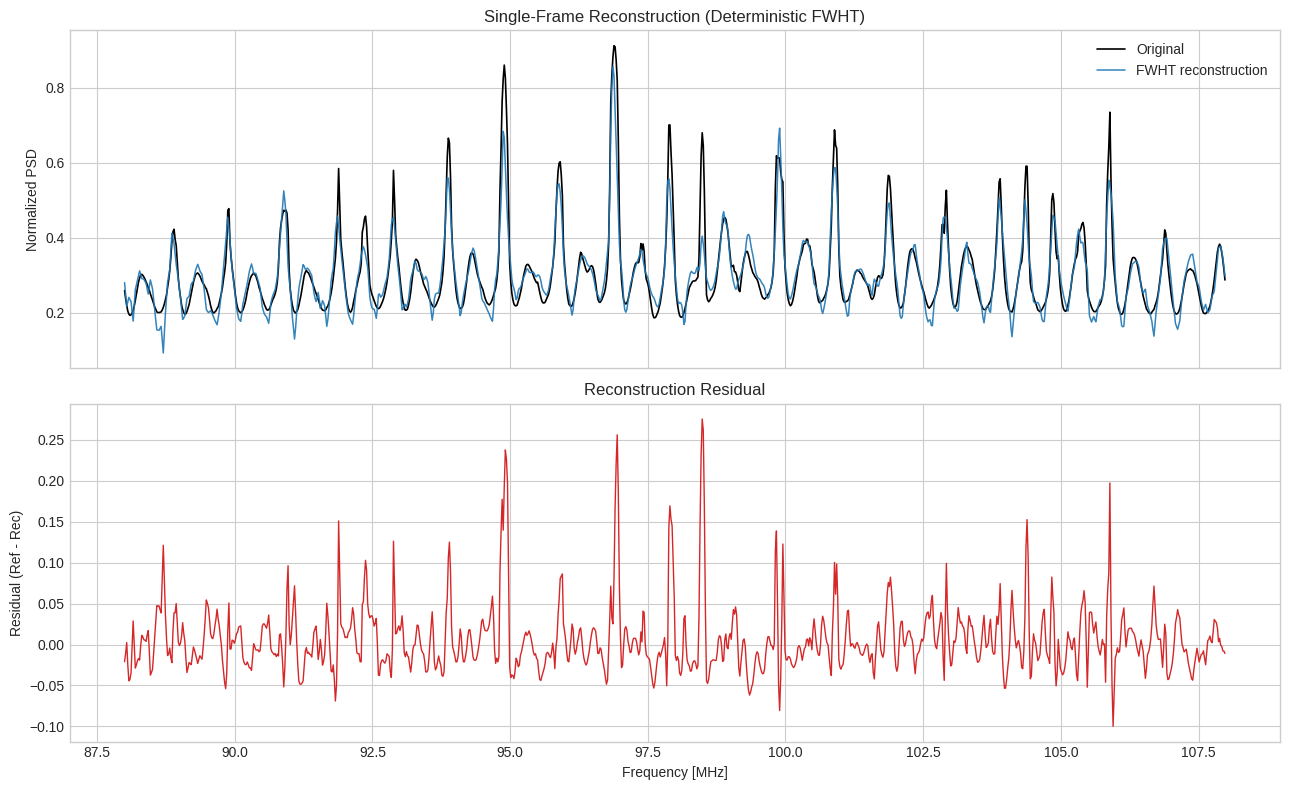

In [26]:
FRAME_INDEX = 0
frame_reference = frames_psd[FRAME_INDEX].astype(np.float64)

packet = compress_fwht_frame(frame_reference, base_config)
frame_estimate = decompress_fwht_frame(packet)

occupancy_threshold = float(np.percentile(frame_reference, 75.0))
frame_metrics = reconstruction_metrics(frame_reference, frame_estimate, freqs_hz, occupancy_threshold)
payload_metrics = estimate_payload_bits(packet, base_config)
operation_metrics = theoretical_operation_counts(frame_reference.size, base_config)

runtime_metrics = benchmark_runtime_ms_per_frame(
    frames_psd,
    base_config,
    bench_indices,
    repeats=3,
)

print('Single-frame reconstruction metrics')
print('-----------------------------------')
for key, value in frame_metrics.items():
    if key.endswith('_khz'):
        print(f'{key:>24s}: {value:12.6f}')
    else:
        print(f'{key:>24s}: {value:12.6e}')

print('\nPayload estimate')
print('----------------')
for key, value in payload_metrics.items():
    if key in {'compression_ratio'}:
        print(f'{key:>24s}: {value:.4f}')
    else:
        print(f'{key:>24s}: {value:.2f}')

print('\nTheoretical per-frame operation counts (approx.)')
print('------------------------------------------------')
for key, value in operation_metrics.items():
    print(f'{key:>24s}: {value:.2f}')

print('\nEmpirical runtime (ms/frame)')
print('----------------------------')
for key, value in runtime_metrics.items():
    print(f'{key:>24s}: {value:.4f}')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Compare original and reconstructed PSD profiles.
axes[0].plot(freqs_hz / 1e6, frame_reference, color='black', linewidth=1.2, label='Original')
axes[0].plot(
    freqs_hz / 1e6,
    frame_estimate,
    color='tab:blue',
    linewidth=1.1,
    alpha=0.9,
    label='FWHT reconstruction',
)
axes[0].set_ylabel('Normalized PSD')
axes[0].set_title('Single-Frame Reconstruction (Deterministic FWHT)')
axes[0].legend(loc='upper right')

# Plot residual to expose systematic distortion patterns.
residual = frame_reference - frame_estimate
axes[1].plot(freqs_hz / 1e6, residual, color='tab:red', linewidth=1.0)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Residual (Ref - Rec)')
axes[1].set_title('Reconstruction Residual')

plt.tight_layout()


In [27]:
TOPK_VALUES = [8, 16, 32, 64, 128, 256]
topk_rows = run_topk_sweep(
    frames_psd=frames_psd,
    freqs_hz=freqs_hz,
    base_config=base_config,
    topk_values=TOPK_VALUES,
    eval_indices=eval_indices,
    bench_indices=bench_indices,
)

print('Top-K sweep summary')
print('-------------------')
header = (
    f"{'K':>6s} {'bits/frame':>12s} {'MSE':>12s} {'NMSE':>12s} {'SNR[dB]':>10s} "
    f"{'occ_mis':>10s} {'peak_err[kHz]':>14s} {'cent_err[kHz]':>14s} {'bw_err[kHz]':>12s} "
    f"{'enc_ms':>10s} {'dec_ms':>10s}"
)
print(header)
for row in topk_rows:
    print(
        f"{int(row['K']):6d} "
        f"{row['avg_bits_per_frame']:12.2f} "
        f"{row['avg_mse']:12.6e} "
        f"{row['avg_nmse']:12.6e} "
        f"{row['avg_snr_db']:10.3f} "
        f"{row['avg_occupancy_mismatch']:10.6f} "
        f"{row['avg_peak_error_khz']:14.3f} "
        f"{row['avg_centroid_error_khz']:14.3f} "
        f"{row['avg_bandwidth_error_khz']:12.3f} "
        f"{row['encode_ms_per_frame_mean']:10.4f} "
        f"{row['decode_ms_per_frame_mean']:10.4f}"
    )


Top-K sweep summary
-------------------
     K   bits/frame          MSE         NMSE    SNR[dB]    occ_mis  peak_err[kHz]  cent_err[kHz]  bw_err[kHz]     enc_ms     dec_ms
     8       258.00 7.460372e-03 6.715970e-02     11.740   0.177017       4019.470         56.882      484.390     1.6591     1.6250
    16       458.00 5.713833e-03 5.142365e-02     12.903   0.133301       5643.082         60.810      230.103     1.6405     1.6005
    32       858.00 3.776004e-03 3.394872e-02     14.722   0.101322       4959.183         63.031      158.997     1.7598     1.7100
    64      1658.00 2.093009e-03 1.882020e-02     17.287   0.072685       3033.371         38.856      104.065     1.7445     1.7037
   128      3258.00 1.003188e-03 9.017809e-03     20.495   0.048080       2864.151         20.299      106.735     1.7295     1.6834
   256      6458.00 3.888102e-04 3.495616e-03     24.627   0.030998       2571.182          6.495       41.351     1.6504     1.6101


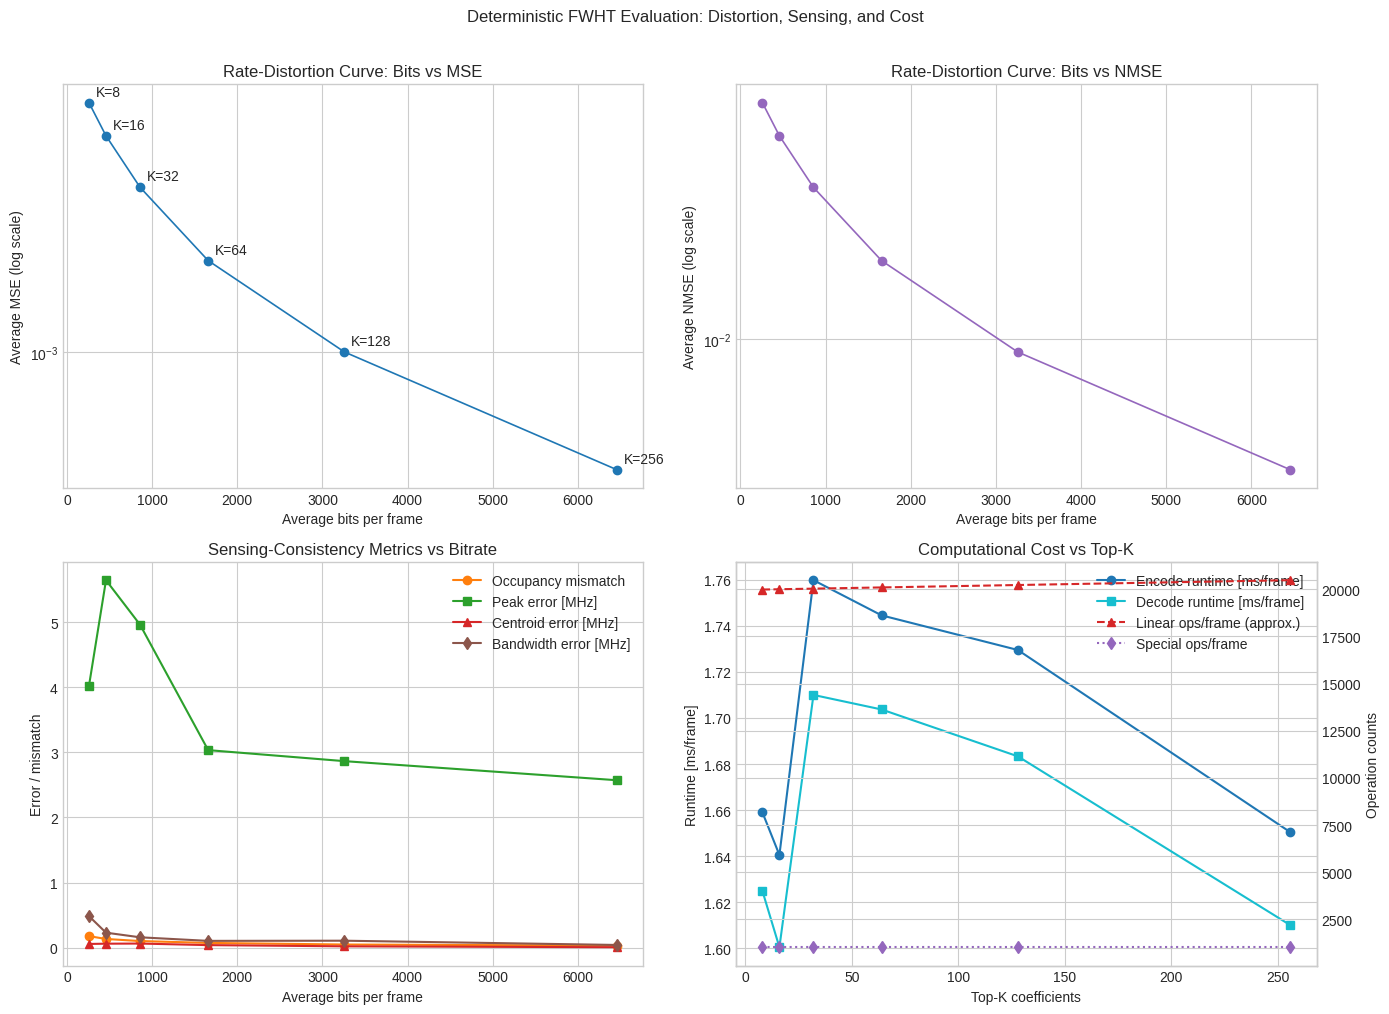

In [28]:
k_axis = np.array([row['K'] for row in topk_rows], dtype=np.float64)
bits_axis = np.array([row['avg_bits_per_frame'] for row in topk_rows], dtype=np.float64)
mse_axis = np.array([row['avg_mse'] for row in topk_rows], dtype=np.float64)
nmse_axis = np.array([row['avg_nmse'] for row in topk_rows], dtype=np.float64)
occ_axis = np.array([row['avg_occupancy_mismatch'] for row in topk_rows], dtype=np.float64)
peak_err_axis = np.array([row['avg_peak_error_khz'] for row in topk_rows], dtype=np.float64)
cent_err_axis = np.array([row['avg_centroid_error_khz'] for row in topk_rows], dtype=np.float64)
bw_err_axis = np.array([row['avg_bandwidth_error_khz'] for row in topk_rows], dtype=np.float64)
enc_ms_axis = np.array([row['encode_ms_per_frame_mean'] for row in topk_rows], dtype=np.float64)
dec_ms_axis = np.array([row['decode_ms_per_frame_mean'] for row in topk_rows], dtype=np.float64)
linear_ops_axis = np.array([row['linear_ops_total'] for row in topk_rows], dtype=np.float64)
special_ops_axis = np.array([row['special_ops'] for row in topk_rows], dtype=np.float64)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rate-distortion view requested by the project objective.
axes[0, 0].plot(bits_axis, mse_axis, marker='o', linewidth=1.2, color='tab:blue')
for k_val, bits, mse in zip(k_axis, bits_axis, mse_axis):
    axes[0, 0].annotate(f'K={int(k_val)}', (bits, mse), textcoords='offset points', xytext=(5, 5))
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('Average bits per frame')
axes[0, 0].set_ylabel('Average MSE (log scale)')
axes[0, 0].set_title('Rate-Distortion Curve: Bits vs MSE')

# Complementary normalized distortion curve.
axes[0, 1].plot(bits_axis, nmse_axis, marker='o', linewidth=1.2, color='tab:purple')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Average bits per frame')
axes[0, 1].set_ylabel('Average NMSE (log scale)')
axes[0, 1].set_title('Rate-Distortion Curve: Bits vs NMSE')

# Sensing consistency metrics vs bitrate.
axes[1, 0].plot(bits_axis, occ_axis, marker='o', label='Occupancy mismatch', color='tab:orange')
axes[1, 0].plot(bits_axis, peak_err_axis / 1e3, marker='s', label='Peak error [MHz]', color='tab:green')
axes[1, 0].plot(bits_axis, cent_err_axis / 1e3, marker='^', label='Centroid error [MHz]', color='tab:red')
axes[1, 0].plot(bits_axis, bw_err_axis / 1e3, marker='d', label='Bandwidth error [MHz]', color='tab:brown')
axes[1, 0].set_xlabel('Average bits per frame')
axes[1, 0].set_ylabel('Error / mismatch')
axes[1, 0].set_title('Sensing-Consistency Metrics vs Bitrate')
axes[1, 0].legend(loc='best')

# Computational cost: runtime and theoretical operation counts.
ax_cost = axes[1, 1]
ax_cost.plot(k_axis, enc_ms_axis, marker='o', label='Encode runtime [ms/frame]', color='tab:blue')
ax_cost.plot(k_axis, dec_ms_axis, marker='s', label='Decode runtime [ms/frame]', color='tab:cyan')
ax_cost.set_xlabel('Top-K coefficients')
ax_cost.set_ylabel('Runtime [ms/frame]')

ax_ops = ax_cost.twinx()
ax_ops.plot(k_axis, linear_ops_axis, marker='^', linestyle='--', label='Linear ops/frame (approx.)', color='tab:red')
ax_ops.plot(k_axis, special_ops_axis, marker='d', linestyle=':', label='Special ops/frame', color='tab:purple')
ax_ops.set_ylabel('Operation counts')

# Merge legends from both y-axes.
lines_a, labels_a = ax_cost.get_legend_handles_labels()
lines_b, labels_b = ax_ops.get_legend_handles_labels()
ax_cost.legend(lines_a + lines_b, labels_a + labels_b, loc='best')
ax_cost.set_title('Computational Cost vs Top-K')

fig.suptitle('Deterministic FWHT Evaluation: Distortion, Sensing, and Cost', y=1.01)
plt.tight_layout()


Decimation sweep summary (Top-K fixed)
--------------------------------------
   decim    N_dec      N_h   bits/frame          MSE    occ_mis     enc_ms     dec_ms      lin_ops
       1     1024     1024      1723.00 2.329135e-03   0.077145     3.3510     3.2381     36992.00
       2      512      512      1658.00 2.093009e-03   0.072685     1.6642     1.6042     20096.00
       4      256      256      1593.00 2.368794e-03   0.086582     0.9056     0.8531     12160.00
       8      128      128      1528.00 5.212180e-03   0.145180     0.4983     0.4692      8448.00


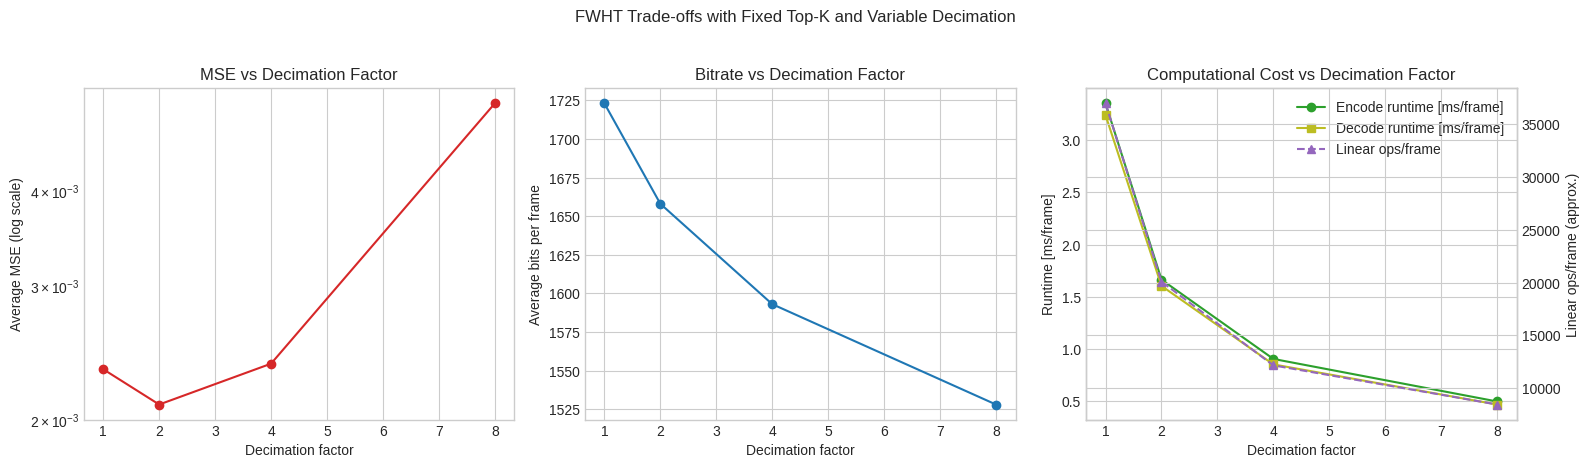

In [29]:
DECIMATION_VALUES = [1, 2, 4, 8]
decimation_rows = run_decimation_sweep(
    frames_psd=frames_psd,
    freqs_hz=freqs_hz,
    base_config=base_config,
    decimation_values=DECIMATION_VALUES,
    eval_indices=eval_indices,
    bench_indices=bench_indices,
)

print('Decimation sweep summary (Top-K fixed)')
print('--------------------------------------')
header = (
    f"{'decim':>8s} {'N_dec':>8s} {'N_h':>8s} {'bits/frame':>12s} {'MSE':>12s} "
    f"{'occ_mis':>10s} {'enc_ms':>10s} {'dec_ms':>10s} {'lin_ops':>12s}"
)
print(header)
for row in decimation_rows:
    print(
        f"{int(row['decimation_factor']):8d} "
        f"{int(row['n_decimated_bins']):8d} "
        f"{int(row['n_hadamard_bins']):8d} "
        f"{row['avg_bits_per_frame']:12.2f} "
        f"{row['avg_mse']:12.6e} "
        f"{row['avg_occupancy_mismatch']:10.6f} "
        f"{row['encode_ms_per_frame_mean']:10.4f} "
        f"{row['decode_ms_per_frame_mean']:10.4f} "
        f"{row['linear_ops_total']:12.2f}"
    )

decim_axis = np.array([row['decimation_factor'] for row in decimation_rows], dtype=np.float64)
decim_mse = np.array([row['avg_mse'] for row in decimation_rows], dtype=np.float64)
decim_bits = np.array([row['avg_bits_per_frame'] for row in decimation_rows], dtype=np.float64)
decim_enc_ms = np.array([row['encode_ms_per_frame_mean'] for row in decimation_rows], dtype=np.float64)
decim_dec_ms = np.array([row['decode_ms_per_frame_mean'] for row in decimation_rows], dtype=np.float64)
decim_ops = np.array([row['linear_ops_total'] for row in decimation_rows], dtype=np.float64)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Distortion impact of stronger frequency decimation.
axes[0].plot(decim_axis, decim_mse, marker='o', color='tab:red')
axes[0].set_yscale('log')
axes[0].set_xlabel('Decimation factor')
axes[0].set_ylabel('Average MSE (log scale)')
axes[0].set_title('MSE vs Decimation Factor')

# Bitrate impact of decimation at fixed K.
axes[1].plot(decim_axis, decim_bits, marker='o', color='tab:blue')
axes[1].set_xlabel('Decimation factor')
axes[1].set_ylabel('Average bits per frame')
axes[1].set_title('Bitrate vs Decimation Factor')

# Cost impact of decimation in runtime and op-count terms.
axes[2].plot(decim_axis, decim_enc_ms, marker='o', label='Encode runtime [ms/frame]', color='tab:green')
axes[2].plot(decim_axis, decim_dec_ms, marker='s', label='Decode runtime [ms/frame]', color='tab:olive')
ax_ops = axes[2].twinx()
ax_ops.plot(decim_axis, decim_ops, marker='^', linestyle='--', color='tab:purple', label='Linear ops/frame')
axes[2].set_xlabel('Decimation factor')
axes[2].set_ylabel('Runtime [ms/frame]')
ax_ops.set_ylabel('Linear ops/frame (approx.)')
axes[2].set_title('Computational Cost vs Decimation Factor')

lines_a, labels_a = axes[2].get_legend_handles_labels()
lines_b, labels_b = ax_ops.get_legend_handles_labels()
axes[2].legend(lines_a + lines_b, labels_a + labels_b, loc='best')

fig.suptitle('FWHT Trade-offs with Fixed Top-K and Variable Decimation', y=1.03)
plt.tight_layout()
